In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn import preprocessing
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import confusion_matrix, roc_auc_score, f1_score, recall_score

In [2]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df['survived'].value_counts()

,count
survived,
0,549
1,342


In [ ]:
# 0 342
# 1 342

In [4]:
df['survived'].value_counts(normalize=True)*100

,proportion
survived,
0,61.616162
1,38.383838


In [6]:
# dari populasi -> sample
# dati 549 -> 342

In [7]:
# populasi -> di DS 33B 10 wanita dan 5 pria (2 : 1)
# ambil 3 perwakilan dari DS 33B
# sample -> 2 wanita dan 1 pria



(891, 15)
(400, 15)


<Axes: xlabel='age', ylabel='Density'>

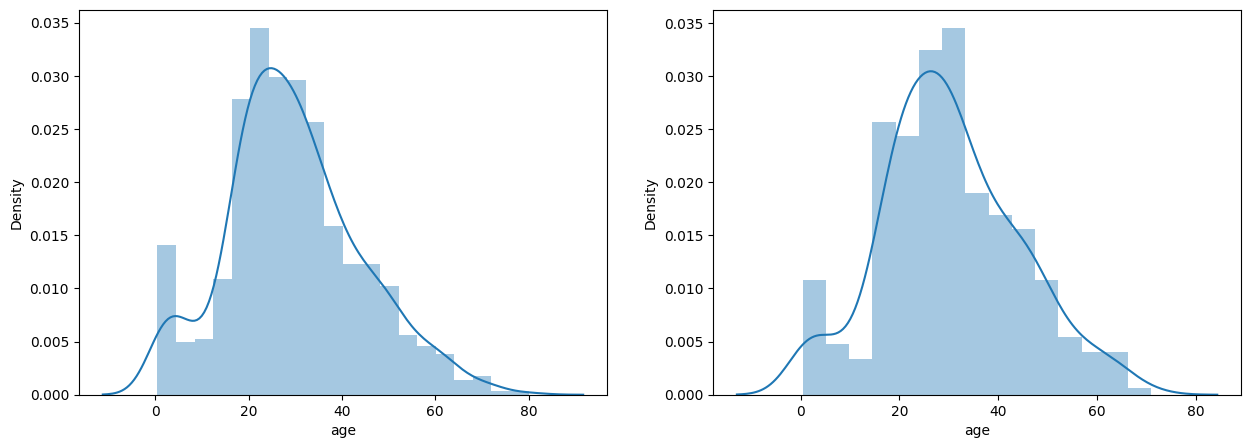

In [15]:
fix, ax = plt.subplots(1,2, figsize=(15,5))
sns.distplot(df['age'], ax=ax[0])
print(df.shape)

df_sample = df.sample(n=400)
print(df_sample.shape)
sns.distplot(df_sample['age'], ax=ax[1])

In [16]:
df_numeric = df[['survived','pclass','age','sibsp','parch','fare']]
df_numeric = df_numeric.dropna()
df_numeric.head()

,survived,pclass,age,sibsp,parch,fare
0,0,3,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,1,3,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,0,3,35.0,0,0,8.0500


In [17]:
df_numeric['survived'].value_counts()

,count
survived,
0,424
1,290


In [18]:
# 0 : 290
# 1 : 290

In [19]:
from imblearn import under_sampling

X = df_numeric.drop(['survived'],axis=1)
y = df_numeric['survived']

# Undersampling
X_under, y_under = under_sampling.RandomUnderSampler().fit_resample(X, y)

In [20]:
df_undersampling = pd.concat([X_under, y_under], axis=1)
df_undersampling.head()

,pclass,age,sibsp,parch,fare,survived
756,3,28.0,0,0,7.7958,0
770,3,24.0,0,0,9.5000,0
30,1,40.0,0,0,27.7208,0
771,3,48.0,0,0,7.8542,0
312,2,26.0,1,1,26.0000,0


In [21]:
df_numeric['survived'].value_counts()

,count
survived,
0,424
1,290


In [22]:
df_undersampling['survived'].value_counts()

,count
survived,
0,290
1,290
